# Hand Gesture EDA — HaGRID Subsets (HuggingFace Edition)
### Preprocessing · EDA · Visualization
#### Google Colab Edition

**Dataset:** [`GestureDetectionConnoisseurs/hagrid_subsets`](https://huggingface.co/datasets/GestureDetectionConnoisseurs/hagrid_subsets/tree/main)  
Pre-packaged subsets of the HaGRID dataset — choose 5 / 100 / 500 / 1000 / 2000 images per class.  
No Kaggle account, no SberCloud — just a direct HuggingFace download.

| Section | Content |
|---|---|
| 1 | Environment setup & imports |
| 2 | Download subset zip from HuggingFace |
| 3 | Dataset structure exploration |
| 4 | Load & merge annotations → DataFrame |
| 5 | Preprocessing pipeline |
| 6 | EDA — Class distribution |
| 7 | EDA — Bounding box analysis |
| 8 | EDA — Leading hand analysis |
| 9 | EDA — Subject / user analysis |
| 10 | Summary dashboard |
| 11 | Save outputs |


---
<a id='1'></a>
## 1. Colab Environment Setup

In [1]:
try:
    import google.colab
    IN_COLAB = True
    print("Running on Google Colab")
except ImportError:
    IN_COLAB = False
    print("Running locally")


Running on Google Colab


In [2]:
# Install required packages
!pip install -q tqdm huggingface_hub

import os, json, zipfile, shutil, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})
print("[SUCCESS] Imports ready")

[SUCCESS] Imports ready


---
<a id='2'></a>
## 2. Download Subset from HuggingFace

Choose how many images **per class** you want:

| Zip file | Images/class | Approx size |
|---|---|---|
| `hagrid-export_5_images.zip` | 5 | 20 MB |
| `hagrid-export_100_images.zip` | 100 | 402 MB |
| `hagrid-export_500_images.zip` | 500 | 2.0 GB |
| `hagrid-export_1000_images.zip` | 1000 | 4.1 GB |
| `hagrid-export_2000_images.zip` | 2000 | 8.1 GB |

Set `IMAGES_PER_CLASS` below and run the cell.


In [3]:
# ── Configuration ─────────────────────────────────────────────────────────
# Choose: 5 | 100 | 500 | 1000 | 2000
IMAGES_PER_CLASS = 500   # ← change this

HF_REPO   = "GestureDetectionConnoisseurs/hagrid_subsets"
ZIP_NAME  = f"hagrid-export_{IMAGES_PER_CLASS}_images.zip"
HF_URL    = f"https://huggingface.co/datasets/{HF_REPO}/resolve/main/{ZIP_NAME}"

# ── Directory layout ───────────────────────────────────────────────────────
CONTENT_DIR  = Path("/content")
DOWNLOAD_DIR = CONTENT_DIR / "hagrid_download"
BASE_DIR     = CONTENT_DIR / "hagrid"
IMAGE_DIR    = BASE_DIR / "images"        # {class}/{img_id}.jpg
ANNOT_DIR    = BASE_DIR / "annotations"  # extracted JSON files land here
OUTPUT_DIR   = CONTENT_DIR / "hagrid_outputs"

for d in [DOWNLOAD_DIR, IMAGE_DIR, ANNOT_DIR, OUTPUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Subset      : {IMAGES_PER_CLASS} images/class")
print(f"HF URL      : {HF_URL}")
print(f"Download dir: {DOWNLOAD_DIR}")
print(f"Image dir   : {IMAGE_DIR}")
print(f"Annot dir   : {ANNOT_DIR}")
print(f"Output dir  : {OUTPUT_DIR}")


Subset      : 500 images/class
HF URL      : https://huggingface.co/datasets/GestureDetectionConnoisseurs/hagrid_subsets/resolve/main/hagrid-export_500_images.zip
Download dir: /content/hagrid_download
Image dir   : /content/hagrid/images
Annot dir   : /content/hagrid/annotations
Output dir  : /content/hagrid_outputs


In [4]:
# ── Download zip from HuggingFace ─────────────────────────────────────────
import subprocess

zip_path = DOWNLOAD_DIR / ZIP_NAME

if zip_path.exists():
    print(f"[SKIP] Already downloaded → {zip_path}  ({zip_path.stat().st_size/1e6:.0f} MB)")
else:
    print(f"[INFO] Downloading {ZIP_NAME} from HuggingFace...")
    result = subprocess.run(
        ["wget", "--show-progress", "-q", "-O", str(zip_path), HF_URL],
        capture_output=False, text=True
    )
    if result.returncode == 0 and zip_path.exists():
        print(f"[SUCCESS] Download complete -> {zip_path.stat().st_size/1e6:.0f} MB")
    else:
        raise RuntimeError(f"Download failed. Check URL: {HF_URL}")

!df -h /content


[INFO] Downloading hagrid-export_500_images.zip from HuggingFace...
[SUCCESS] Download complete -> 2029 MB
Filesystem      Size  Used Avail Use% Mounted on
overlay         236G   45G  191G  19% /


In [5]:
# ── Extract zip: images → IMAGE_DIR, annotation JSONs → ANNOT_DIR ─────────
# Zip internal layout:
#   {class_name}/{img_id}.jpg   → extracted to IMAGE_DIR/{class_name}/{img_id}.jpg
#   annotations.json            → copied to ANNOT_DIR/annotations.json
#   minimal-annotations.json    → copied to ANNOT_DIR/minimal-annotations.json
#   exported_images.json        → copied to ANNOT_DIR/exported_images.json

print("[INFO] Scanning zip contents...")
with zipfile.ZipFile(zip_path, "r") as z:
    all_members = z.namelist()

img_members  = [m for m in all_members if m.lower().endswith(".jpg")]
json_members = [m for m in all_members if m.lower().endswith(".json")]

print(f"  Images in zip : {len(img_members):,}")
print(f"  JSON files    : {json_members}")

already_extracted = list(IMAGE_DIR.rglob("*.jpg"))
if len(already_extracted) >= len(img_members) * 0.99:
    print(f"[SKIP] Images already extracted ({len(already_extracted):,} found)")
else:
    print("[INFO] Extracting images...")
    with zipfile.ZipFile(zip_path, "r") as z:
        for member in tqdm(img_members, desc="Images"):
            dest = IMAGE_DIR / member
            dest.parent.mkdir(parents=True, exist_ok=True)
            with z.open(member) as src, open(dest, "wb") as dst:
                dst.write(src.read())

    print("[INFO] Extracting annotation JSONs...")
    with zipfile.ZipFile(zip_path, "r") as z:
        for jf in json_members:
            dest = ANNOT_DIR / Path(jf).name
            with z.open(jf) as src, open(dest, "wb") as dst:
                dst.write(src.read())

print(f"\n[SUCCESS] Extraction complete")
print(f"  Images : {len(list(IMAGE_DIR.rglob('*.jpg'))):,} files")
print(f"  JSONs  : {list(ANNOT_DIR.iterdir())}")


[INFO] Scanning zip contents...
  Images in zip : 17,000
  JSON files    : ['minimal-annotations.json', 'annotations.json', 'exported_images.json']
[INFO] Extracting images...


Images:   0%|          | 0/17000 [00:00<?, ?it/s]

[INFO] Extracting annotation JSONs...

[SUCCESS] Extraction complete
  Images : 17,000 files
  JSONs  : [PosixPath('/content/hagrid/annotations/minimal-annotations.json'), PosixPath('/content/hagrid/annotations/annotations.json'), PosixPath('/content/hagrid/annotations/exported_images.json')]


---
<a id='3'></a>
## 3. Dataset Structure Exploration

In [6]:
ALL_GESTURE_CLASSES = [
    "call", "dislike", "fist", "four", "like", "mute", "ok", "one",
    "palm", "peace", "peace_inverted", "rock", "stop", "stop_inverted",
    "three", "three2", "two_up", "two_up_inverted", "no_gesture"
]

PALETTE   = plt.get_cmap("tab20", len(ALL_GESTURE_CLASSES))
COLOR_MAP = {cls: PALETTE(i) for i, cls in enumerate(ALL_GESTURE_CLASSES)}

# ── Class folders on disk ──────────────────────────────────────────────────
class_dirs = sorted([d for d in IMAGE_DIR.iterdir() if d.is_dir()])
print(f"Classes found on disk: {len(class_dirs)}")
print(f"{'Class':<22} {'Images':>8}")
print("-" * 32)
for d in class_dirs:
    n = len(list(d.glob("*.jpg")))
    print(f"  {d.name:<20} {n:>8,}")


Classes found on disk: 34
Class                    Images
--------------------------------
  call                      500
  dislike                   500
  fist                      500
  four                      500
  grabbing                  500
  grip                      500
  hand_heart                500
  hand_heart2               500
  holy                      500
  like                      500
  little_finger             500
  middle_finger             500
  mute                      500
  no_gesture                500
  ok                        500
  one                       500
  palm                      500
  peace                     500
  peace_inverted            500
  point                     500
  rock                      500
  stop                      500
  stop_inverted             500
  take_picture              500
  three                     500
  three2                    500
  three3                    500
  three_gun                 500
  thumb_index

In [7]:
# ── Peek at annotations.json ───────────────────────────────────────────────
ann_path = ANNOT_DIR / "annotations.json"

with open(ann_path) as f:
    raw_ann = json.load(f)

print(f"Top-level keys (gesture classes): {list(raw_ann.keys())}")
print(f"\nImages per class in annotations:")
for cls, entries in raw_ann.items():
    print(f"  {cls:<22} {len(entries):>6,}")

# Show one sample entry
sample_class = next(iter(raw_ann))
sample_id    = next(iter(raw_ann[sample_class]))
sample_entry = raw_ann[sample_class][sample_id]
print(f"\nSample entry  [{sample_class} / {sample_id}]:")
print(json.dumps(sample_entry, indent=2)[:800])


Top-level keys (gesture classes): ['peace', 'two_up', 'stop_inverted', 'three', 'stop', 'rock', 'three2', 'dislike', 'four', 'mute', 'palm', 'two_up_inverted', 'peace_inverted', 'one', 'ok', 'fist', 'call', 'like', 'call-checkpoint', 'four-checkpoint', 'hand_heart-checkpoint', 'grip-checkpoint', 'peace-checkpoint', 'no_gesture', 'three3', 'little_finger', 'thumb_index', 'three_gun', 'middle_finger', 'grip', 'point', 'thumb_index2', 'hand_heart', 'grabbing', 'xsign', 'take_picture', 'hand_heart2', 'holy', 'timeout', 'thumb_index2-checkpoint', 'dislike-checkpoint', 'peace_inverted-checkpoint', 'three3-checkpoint', 'thumb_index-checkpoint']

Images per class in annotations:
  peace                     500
  two_up                    500
  stop_inverted             500
  three                     500
  stop                      500
  rock                      500
  three2                    500
  dislike                   500
  four                      500
  mute                      500


---
<a id='4'></a>
## 4. Load & Merge Annotations

In [8]:
def load_annotations(raw_ann: dict, images_per_class: int) -> pd.DataFrame:
    """
    Parse the HuggingFace subset annotations.json into a flat DataFrame.
    One row = one bounding box.

    Schema
    ------
    img_id         : str   — unique image UUID
    gesture_class  : str   — folder / top-level class (e.g. 'call')
    label          : str   — per-box gesture label (from the 'labels' list)
    bbox_x         : float — normalised left edge  [0, 1]
    bbox_y         : float — normalised top edge   [0, 1]
    bbox_w         : float — normalised width      [0, 1]
    bbox_h         : float — normalised height     [0, 1]
    bbox_area      : float — bbox_w × bbox_h
    aspect_ratio   : float — bbox_w / bbox_h
    leading_hand   : str   — 'right' | 'left' | None
    leading_conf   : float — confidence of hand-dominance prediction
    user_id        : str   — anonymous subject ID
    n_boxes        : int   — total boxes in this image
    is_no_gesture  : bool  — True when label == 'no_gesture'
    split          : str   — assigned below (train / val / test)
    img_path       : Path  — absolute path to the JPEG on disk
    """
    records = []
    for gesture_class, entries in tqdm(raw_ann.items(), desc="Loading annotations"):
        for img_id, ann in entries.items():
            labels  = ann.get("labels", [gesture_class])   # fallback to class name
            bboxes  = ann.get("bboxes", [])
            meta    = ann.get("meta",   {})
            leading_hand = ann.get("leading_hand") or meta.get("leading_hand")
            leading_conf = ann.get("leading_conf") or meta.get("leading_conf")
            user_id      = ann.get("user_id")      or meta.get("user_id")
            n_boxes      = len(bboxes)

            img_path = IMAGE_DIR / gesture_class / f"{img_id}.jpg"

            for label, bbox in zip(labels, bboxes):
                x, y, w, h = (bbox if len(bbox) == 4 else (bbox + [0, 0, 0, 0])[:4])
                records.append({
                    "img_id"        : img_id,
                    "gesture_class" : gesture_class,
                    "label"         : label,
                    "bbox_x"        : float(x),
                    "bbox_y"        : float(y),
                    "bbox_w"        : float(w),
                    "bbox_h"        : float(h),
                    "bbox_area"     : float(w) * float(h),
                    "aspect_ratio"  : float(w) / float(h) if float(h) > 0 else 0.0,
                    "leading_hand"  : leading_hand,
                    "leading_conf"  : leading_conf,
                    "user_id"       : user_id,
                    "n_boxes"       : n_boxes,
                    "is_no_gesture" : label == "no_gesture",
                    "split"         : "train",   # placeholder — assigned below
                    "img_path"      : img_path,
                })

    return pd.DataFrame(records)

df = load_annotations(raw_ann, IMAGES_PER_CLASS)
print(f"\nRaw DataFrame: {len(df):,} rows × {len(df.columns)} cols")
print(df.head(3).to_string())


Loading annotations:   0%|          | 0/44 [00:00<?, ?it/s]


Raw DataFrame: 23,609 rows × 16 cols
                                 img_id gesture_class       label    bbox_x    bbox_y    bbox_w    bbox_h  bbox_area  aspect_ratio leading_hand leading_conf                                                           user_id  n_boxes  is_no_gesture  split                                                               img_path
0  6194643b-bcd0-4d3c-8e45-94059ac271dd         peace       peace  0.302461  0.327982  0.082919  0.107959   0.008952      0.768057         None         None  c163c20552d2bcaee7f44d1ba772f4bac6c856d0aa916589d4e38e7f438ce244        2          False  train  /content/hagrid/images/peace/6194643b-bcd0-4d3c-8e45-94059ac271dd.jpg
1  6194643b-bcd0-4d3c-8e45-94059ac271dd         peace  no_gesture  0.612090  0.596739  0.066601  0.073424   0.004890      0.907070         None         None  c163c20552d2bcaee7f44d1ba772f4bac6c856d0aa916589d4e38e7f438ce244        2           True  train  /content/hagrid/images/peace/6194643b-bcd0-4d3c-8e45-9405

In [9]:
# ── Assign train / val / test splits ──────────────────────────────────────
# The HuggingFace subsets don't ship with pre-defined splits, so we create
# a random 80 / 10 / 10 split stratified by gesture class.

def make_splits(df: pd.DataFrame, seed: int = SEED) -> pd.DataFrame:
    df = df.copy()
    rng = np.random.default_rng(seed)

    split_col = []
    unique_imgs = df[["img_id", "gesture_class"]].drop_duplicates()

    val_ids  = set()
    test_ids = set()

    for cls, grp in unique_imgs.groupby("gesture_class"):
        ids = grp["img_id"].values.copy()
        rng.shuffle(ids)
        n = len(ids)
        val_ids  |= set(ids[int(n*0.80):int(n*0.90)])
        test_ids |= set(ids[int(n*0.90):])

    def _split(img_id):
        if img_id in val_ids:  return "val"
        if img_id in test_ids: return "test"
        return "train"

    df["split"] = df["img_id"].apply(_split)
    return df

df = make_splits(df)

print("Split distribution (bounding boxes):")
print(df["split"].value_counts())
print("\nSplit distribution (unique images):")
print(df.groupby("split")["img_id"].nunique())

# Convenience per-image view (one row per image, not per bbox)
df_img = (
    df.groupby("img_id", as_index=False)
    .agg(
        gesture_class=("gesture_class", "first"),
        split        =("split",         "first"),
        user_id      =("user_id",       "first"),
        leading_hand =("leading_hand",  "first"),
        leading_conf =("leading_conf",  "first"),
        n_boxes      =("n_boxes",       "first"),
        img_path     =("img_path",      "first"),
    )
)
print(f"\nPer-image DataFrame: {len(df_img):,} rows")


Split distribution (bounding boxes):
split
train    18840
test      2385
val       2384
Name: count, dtype: int64

Split distribution (unique images):
split
test      1700
train    13592
val       1699
Name: img_id, dtype: int64

Per-image DataFrame: 16,991 rows


---
<a id='5'></a>
## 5. Preprocessing Pipeline

In [10]:
# ── 5.1 dtype & missing values ────────────────────────────────────────────
print("=== dtype overview ===")
print(df.dtypes)

print("\n=== Missing values ===")
print(df.isnull().sum())

# ── 5.2 BBox coordinate sanity check ─────────────────────────────────────
print("\n=== BBox coordinate sanity check ===")
out_of_range = df[
    (df["bbox_x"] < 0) | (df["bbox_y"] < 0) |
    (df["bbox_x"] + df["bbox_w"] > 1) |
    (df["bbox_y"] + df["bbox_h"] > 1)
]
print(f"Boxes out of [0, 1] range: {len(out_of_range):,}")

# ── 5.3 Clip bboxes to [0, 1] ────────────────────────────────────────────
df["bbox_x"] = df["bbox_x"].clip(0, 1)
df["bbox_y"] = df["bbox_y"].clip(0, 1)
df["bbox_w"] = (df["bbox_x"] + df["bbox_w"]).clip(0, 1) - df["bbox_x"]
df["bbox_h"] = (df["bbox_y"] + df["bbox_h"]).clip(0, 1) - df["bbox_y"]
df["bbox_area"]    = df["bbox_w"] * df["bbox_h"]
df["aspect_ratio"] = df["bbox_w"] / df["bbox_h"].replace(0, np.nan)
df["bbox_cx"]      = df["bbox_x"] + df["bbox_w"] / 2
df["bbox_cy"]      = df["bbox_y"] + df["bbox_h"] / 2

# ── 5.4 Drop degenerate boxes ─────────────────────────────────────────────
before = len(df)
df = df[(df["bbox_w"] > 0) & (df["bbox_h"] > 0)].reset_index(drop=True)
print(f"\nDropped {before - len(df)} degenerate boxes — {len(df):,} remain.")

# ── 5.5 Convenience column ────────────────────────────────────────────────
df["is_no_gesture"] = df["label"] == "no_gesture"

# ── 5.6 Per-image summary ─────────────────────────────────────────────────
df_img = (
    df.groupby(["img_id", "split", "gesture_class", "user_id"])
    .agg(
        n_boxes      = ("label", "count"),
        labels       = ("label", list),
        mean_area    = ("bbox_area", "mean"),
        leading_hand = ("leading_hand", "first"),
        leading_conf = ("leading_conf", "first"),
    )
    .reset_index()
)
df_img["n_hands"] = df_img["n_boxes"]

print(f"\nPer-image dataframe: {len(df_img):,} rows")
df_img.head(3)

=== dtype overview ===
img_id            object
gesture_class     object
label             object
bbox_x           float64
bbox_y           float64
bbox_w           float64
bbox_h           float64
bbox_area        float64
aspect_ratio     float64
leading_hand      object
leading_conf      object
user_id           object
n_boxes            int64
is_no_gesture       bool
split             object
img_path          object
dtype: object

=== Missing values ===
img_id               0
gesture_class        0
label                0
bbox_x               0
bbox_y               0
bbox_w               0
bbox_h               0
bbox_area            0
aspect_ratio         0
leading_hand     23609
leading_conf     23609
user_id            108
n_boxes              0
is_no_gesture        0
split                0
img_path             0
dtype: int64

=== BBox coordinate sanity check ===
Boxes out of [0, 1] range: 2

Dropped 0 degenerate boxes — 23,609 remain.

Per-image dataframe: 16,899 rows


,img_id,split,gesture_class,user_id,n_boxes,labels,mean_area,leading_hand,leading_conf,n_hands
0,000003eb-7813-433b-8814-258dc765d3f3,train,grip,a8fa668e0b527a529b505b82112b97c4,1,[grip],0.013179,None,None,1
1,00001bb7-a8d2-4561-9e86-c94708108d32,train,three_gun,0fc107c58e86ed0e2acb1e3be9a1f380,1,[three_gun],0.065696,None,None,1
2,000053e0-139d-4918-be2d-89b388732a4b,train,middle_finger,a50f44ba9ddd5000bfec88f7fd2aa1ba,1,[middle_finger],0.033931,None,None,1


---
<a id='6'></a>
## 6. EDA — Class Distribution

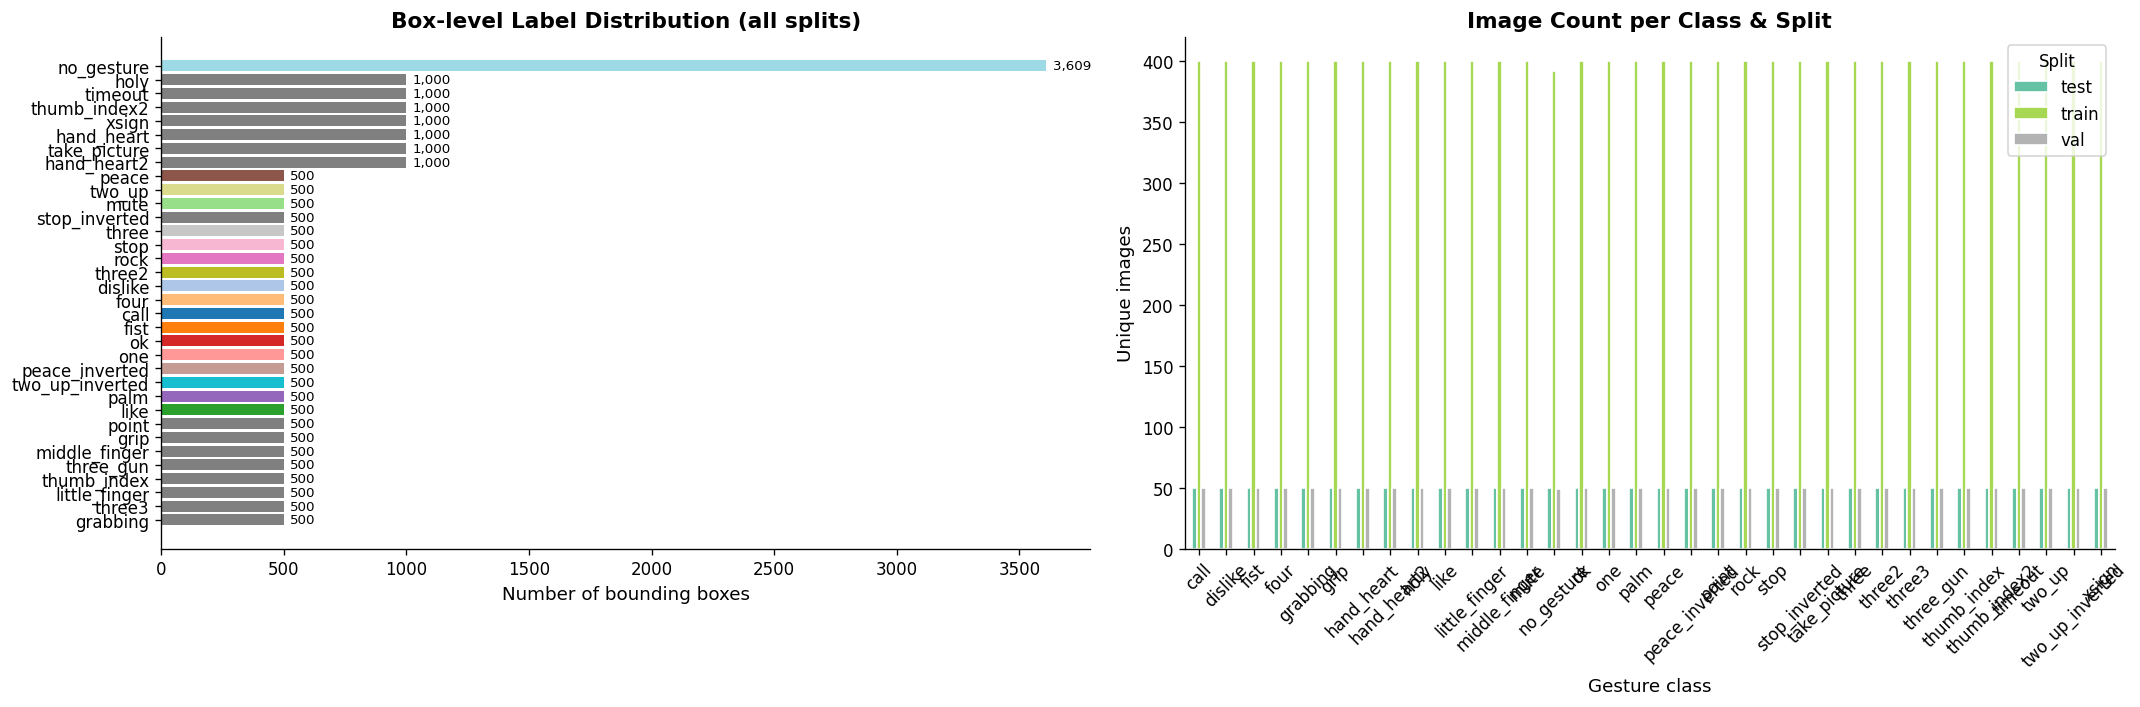

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ── 6.1 Overall box label distribution ───────────────────────────────────
label_counts = df["label"].value_counts()
colors = [COLOR_MAP.get(l, (0.5, 0.5, 0.5, 1)) for l in label_counts.index]

ax = axes[0]
bars = ax.barh(label_counts.index, label_counts.values, color=colors)
ax.bar_label(bars, labels=[f"{v:,}" for v in label_counts.values], padding=4, fontsize=8)
ax.set_xlabel("Number of bounding boxes")
ax.set_title("Box-level Label Distribution (all splits)", fontweight="bold")
ax.invert_yaxis()

# ── 6.2 Image count per class & split ────────────────────────────────────
ax = axes[1]
split_label = (
    df.groupby(["split", "gesture_class"])["img_id"]
    .nunique()
    .unstack("split")
    .fillna(0)
    .astype(int)
)
split_label.plot(kind="bar", ax=ax, colormap="Set2", edgecolor="white")
ax.set_xlabel("Gesture class")
ax.set_ylabel("Unique images")
ax.set_title("Image Count per Class & Split", fontweight="bold")
ax.tick_params(axis="x", rotation=45)
ax.legend(title="Split")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "class_distribution.png", bbox_inches="tight")
plt.show()

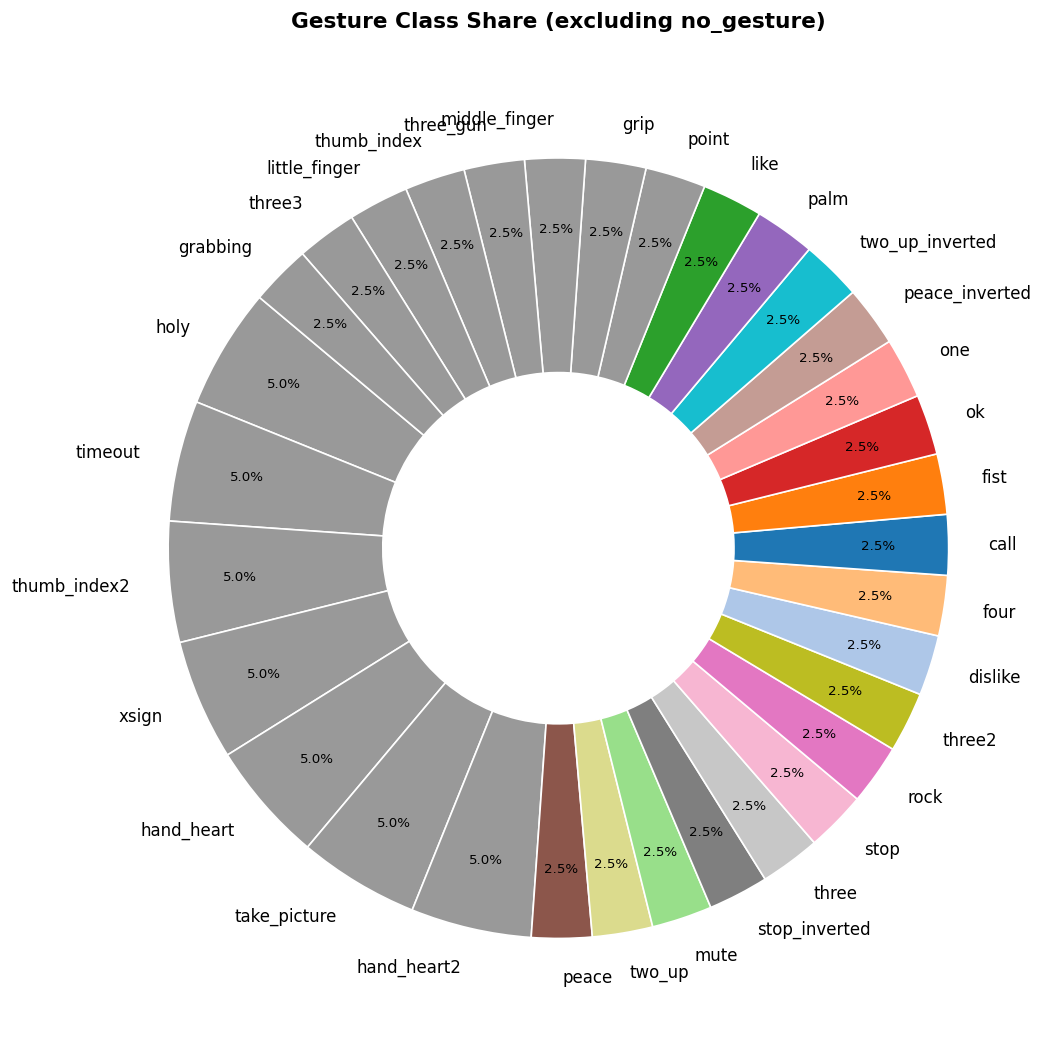

In [12]:
# ── 6.3 Donut chart — gesture share (excluding no_gesture) ───────────────
gesture_only = label_counts[label_counts.index != "no_gesture"]

fig, ax = plt.subplots(figsize=(9, 9))
wedge_colors = [COLOR_MAP.get(l, (0.6, 0.6, 0.6, 1)) for l in gesture_only.index]
wedges, texts, autotexts = ax.pie(
    gesture_only.values,
    labels=gesture_only.index,
    colors=wedge_colors,
    autopct="%1.1f%%",
    pctdistance=0.82,
    startangle=140,
    wedgeprops=dict(width=0.55, edgecolor="white"),
)
for at in autotexts:
    at.set_fontsize(8)
ax.set_title("Gesture Class Share (excluding no_gesture)",
             fontweight="bold", pad=20)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "class_pie.png", bbox_inches="tight")
plt.show()

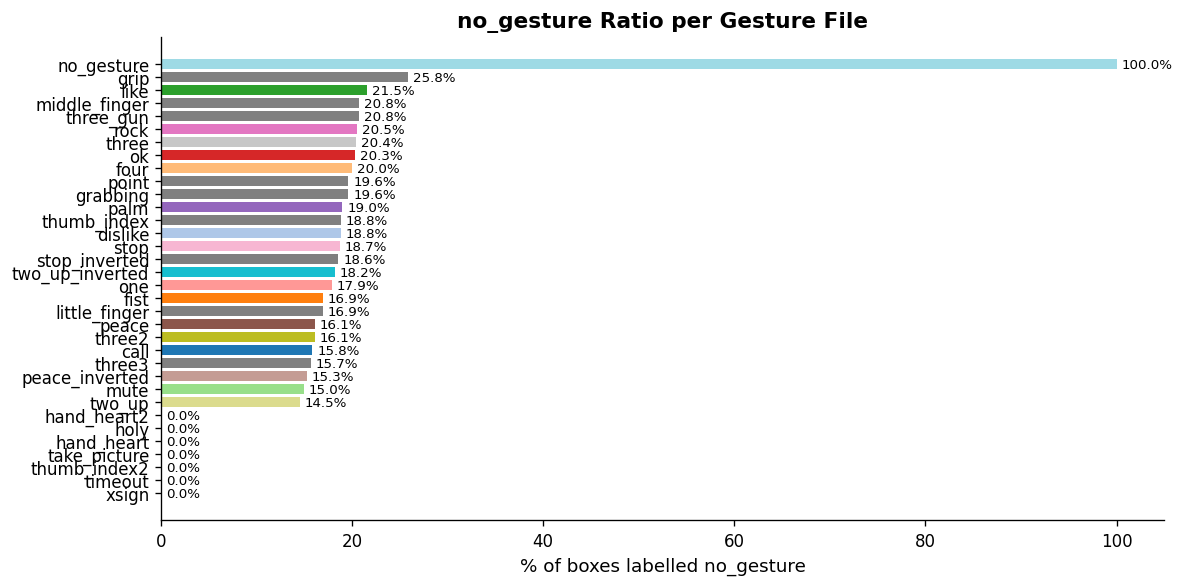

In [13]:
# ── 6.4 no_gesture ratio per class ───────────────────────────────────────
ng_ratio = (
    df.groupby("gesture_class")["is_no_gesture"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(
    ng_ratio.index, ng_ratio.values,
    color=[COLOR_MAP.get(c, (0.5, 0.5, 0.5, 1)) for c in ng_ratio.index]
)
ax.bar_label(bars, labels=[f"{v:.1f}%" for v in ng_ratio.values], padding=3, fontsize=8)
ax.set_xlabel("% of boxes labelled no_gesture")
ax.set_title("no_gesture Ratio per Gesture File", fontweight="bold")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "no_gesture_ratio.png", bbox_inches="tight")
plt.show()

---
<a id='7'></a>
## 7. EDA — Bounding Box Analysis

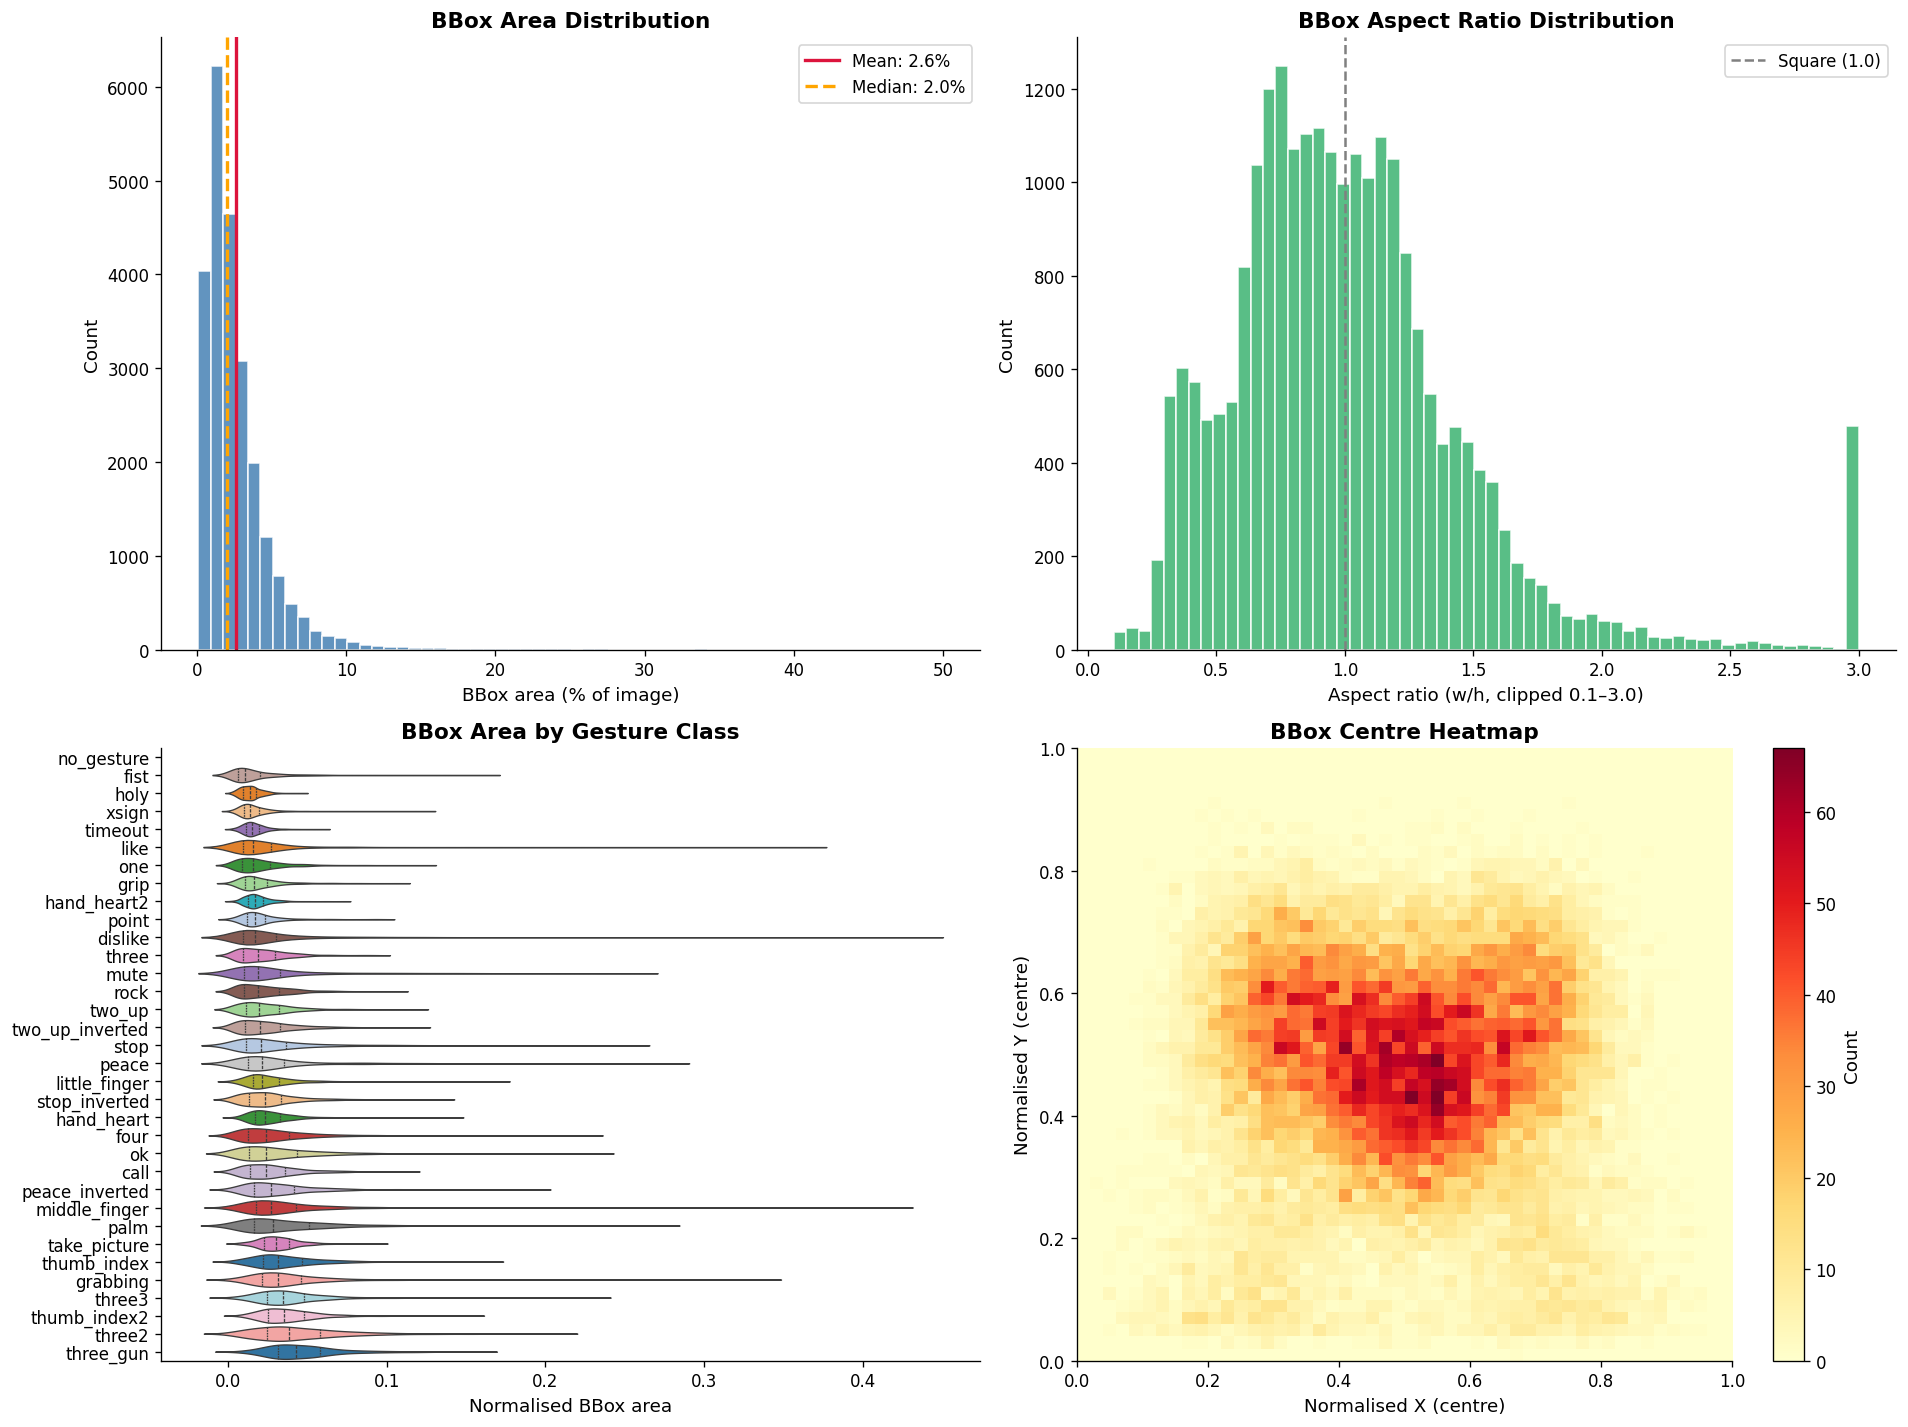

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ── 7.1 Area distribution ─────────────────────────────────────────────────
ax = axes[0, 0]
ax.hist(df["bbox_area"] * 100, bins=60, color="steelblue", edgecolor="white", alpha=0.85)
ax.axvline(df["bbox_area"].mean() * 100, color="crimson", lw=2,
           label=f"Mean: {df['bbox_area'].mean()*100:.1f}%")
ax.axvline(df["bbox_area"].median() * 100, color="orange", lw=2, ls="--",
           label=f"Median: {df['bbox_area'].median()*100:.1f}%")
ax.set_xlabel("BBox area (% of image)")
ax.set_ylabel("Count")
ax.set_title("BBox Area Distribution", fontweight="bold")
ax.legend()

# ── 7.2 Aspect ratio distribution ────────────────────────────────────────
ax = axes[0, 1]
ar_clip = df["aspect_ratio"].dropna().clip(0.1, 3.0)
ax.hist(ar_clip, bins=60, color="mediumseagreen", edgecolor="white", alpha=0.85)
ax.axvline(1.0, color="grey", lw=1.5, ls="--", label="Square (1.0)")
ax.set_xlabel("Aspect ratio (w/h, clipped 0.1–3.0)")
ax.set_ylabel("Count")
ax.set_title("BBox Aspect Ratio Distribution", fontweight="bold")
ax.legend()

# ── 7.3 Violin — area by class ────────────────────────────────────────────
ax = axes[1, 0]
filtered_df = df[~df["is_no_gesture"]]
sample_size = min(50_000, len(filtered_df))
sample_df = filtered_df.sample(sample_size, random_state=SEED)
order = df.groupby("label")["bbox_area"].median().sort_values().index.tolist()
sns.violinplot(
    data=sample_df, x="bbox_area", y="label", hue="label",
    order=order, palette="tab20", inner="quartile", ax=ax, linewidth=0.8, legend=False
)
ax.set_xlabel("Normalised BBox area")
ax.set_ylabel("")
ax.set_title("BBox Area by Gesture Class", fontweight="bold")

# ── 7.4 BBox centre heatmap ───────────────────────────────────────────────
ax = axes[1, 1]
h2d, xedges, yedges = np.histogram2d(
    df["bbox_cx"].values, df["bbox_cy"].values,
    bins=50, range=[[0, 1], [0, 1]]
)
im = ax.imshow(h2d.T, origin="upper", extent=[0, 1, 0, 1],
               cmap="YlOrRd", aspect="auto", interpolation="nearest")
plt.colorbar(im, ax=ax, label="Count")
ax.set_xlabel("Normalised X (centre)")
ax.set_ylabel("Normalised Y (centre)")
ax.set_title("BBox Centre Heatmap", fontweight="bold")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "bbox_analysis.png", bbox_inches="tight")
plt.show()

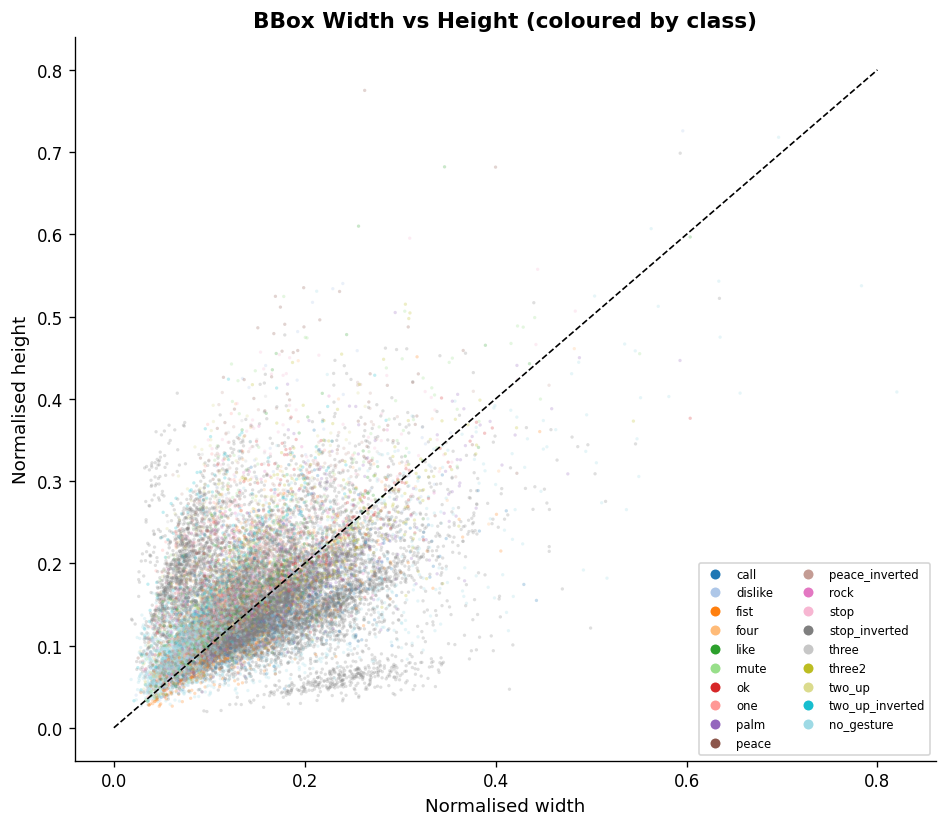

In [15]:
from matplotlib.lines import Line2D

# ── 7.5 Width vs Height scatter ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))
scatter_df = df.sample(min(20_000, len(df)), random_state=SEED)
scatter_colors = [COLOR_MAP.get(l, (0.5, 0.5, 0.5, 0.4)) for l in scatter_df["label"]]
ax.scatter(scatter_df["bbox_w"], scatter_df["bbox_h"],
           c=scatter_colors, alpha=0.25, s=4, linewidths=0)
ax.plot([0, 0.8], [0, 0.8], "k--", lw=1, label="Square (w=h)")
ax.set_xlabel("Normalised width")
ax.set_ylabel("Normalised height")
ax.set_title("BBox Width vs Height (coloured by class)", fontweight="bold")
legend_els = [
    Line2D([0], [0], marker="o", color="w",
           markerfacecolor=COLOR_MAP.get(c, (0.5, 0.5, 0.5, 1)),
           markersize=7, label=c)
    for c in ALL_GESTURE_CLASSES if c in df["label"].unique()
]
ax.legend(handles=legend_els, loc="lower right", fontsize=7, ncol=2, framealpha=0.8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "bbox_wh_scatter.png", bbox_inches="tight")
plt.show()

In [16]:
# ── 7.6 BBox statistics per class ─────────────────────────────────────────
bbox_stats = (
    df.groupby("label")[["bbox_area", "bbox_w", "bbox_h", "aspect_ratio"]]
    .agg(["mean", "median", "std"])
    .round(4)
)
bbox_stats.columns = ["_".join(c) for c in bbox_stats.columns]
print("BBox statistics per label:")
display(bbox_stats)

BBox statistics per label:


,bbox_area_mean,bbox_area_median,bbox_area_std,bbox_w_mean,bbox_w_median,bbox_w_std,bbox_h_mean,bbox_h_median,bbox_h_std,aspect_ratio_mean,aspect_ratio_median,aspect_ratio_std
label,,,,,,,,,,,,
call,0.0279,0.0243,0.0185,0.1740,0.1678,0.0662,0.1486,0.1396,0.0579,1.2414,1.2861,0.4089
dislike,0.0259,0.0173,0.0304,0.1330,0.1206,0.0649,0.1630,0.1418,0.0878,0.8717,0.9163,0.2620
fist,0.0170,0.0111,0.0184,0.1308,0.1167,0.0662,0.1091,0.0958,0.0552,1.2623,1.2981,0.3859
four,0.0294,0.0241,0.0237,0.1496,0.1407,0.0644,0.1750,0.1644,0.0716,0.8869,0.9099,0.2458
grabbing,0.0389,0.0319,0.0294,0.2092,0.1986,0.0765,0.1713,0.1602,0.0601,1.2556,1.2445,0.3278
grip,0.0199,0.0163,0.0136,0.1443,0.1365,0.0503,0.1273,0.1194,0.0442,1.1738,1.1513,0.2960
hand_heart,0.0265,0.0238,0.0138,0.1555,0.1528,0.0431,0.1637,0.1584,0.0495,0.9877,0.9802,0.2499
hand_heart2,0.0181,0.0169,0.0076,0.1453,0.1435,0.0358,0.1218,0.1175,0.0342,1.2462,1.2349,0.3287
holy,0.0144,0.0138,0.0067,0.0687,0.0688,0.0202,0.2025,0.1983,0.0543,0.3502,0.3437,0.0959


---
<a id='8'></a>
## 8. EDA — Leading Hand Analysis

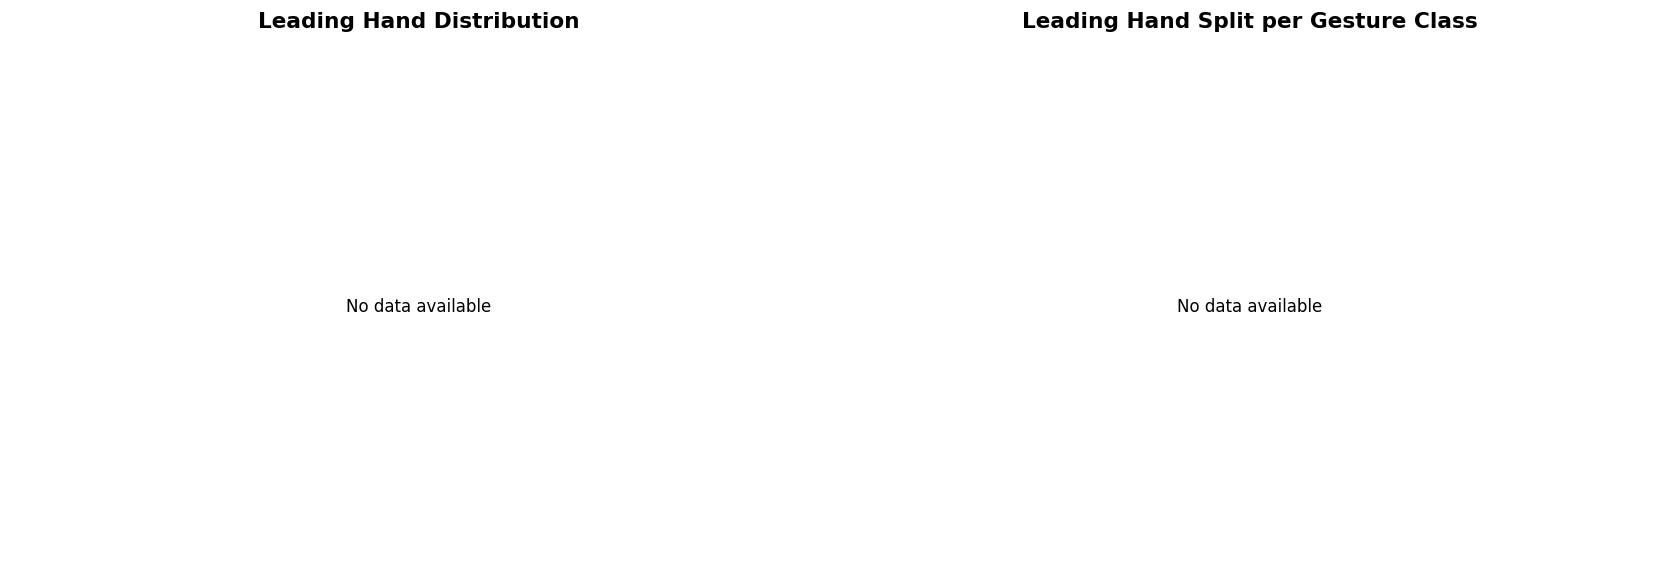

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── 8.1 Overall pie ───────────────────────────────────────────────────────
hand_counts = df_img["leading_hand"].value_counts().dropna()
ax = axes[0]
if not hand_counts.empty:
    ax.pie(
        hand_counts.values,
        labels=[f"{k}\n({v:,})" for k, v in hand_counts.items()],
        colors=["#4C9BE8", "#E85C4C"],
        autopct="%1.1f%%",
        startangle=90,
        wedgeprops=dict(edgecolor="white", linewidth=2),
    )
else:
    ax.text(0.5, 0.5, "No data available", ha="center", va="center")
    ax.axis("off")
ax.set_title("Leading Hand Distribution", fontweight="bold")

# ── 8.2 Per-class stacked % bar ───────────────────────────────────────────
ax = axes[1]
lh_cls = (
    df_img.dropna(subset=["leading_hand"])
    .groupby(["gesture_class", "leading_hand"])["img_id"]
    .nunique()
    .unstack("leading_hand")
    .fillna(0)
)

if not lh_cls.empty:
    lh_cls_pct = lh_cls.div(lh_cls.sum(axis=1), axis=0) * 100
    lh_cls_pct.plot(kind="barh", stacked=True, ax=ax,
                    color=["#4C9BE8", "#E85C4C"], edgecolor="white")
    ax.set_xlabel("% of images")
    ax.set_ylabel("")
    ax.legend(title="Leading hand")
    ax.axvline(50, color="black", lw=1, ls="--", alpha=0.5)
else:
    ax.text(0.5, 0.5, "No data available", ha="center", va="center")
    ax.axis("off")
ax.set_title("Leading Hand Split per Gesture Class", fontweight="bold")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "leading_hand.png", bbox_inches="tight")
plt.show()


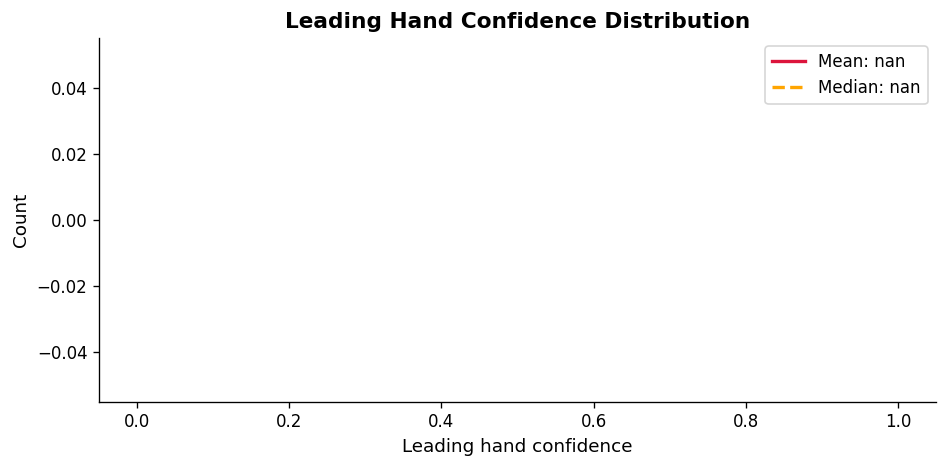

In [18]:
# ── 8.3 Leading hand confidence distribution ──────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
conf_data = df_img["leading_conf"].dropna()
ax.hist(conf_data, bins=50, color="#4C9BE8", edgecolor="white", alpha=0.85)
ax.axvline(conf_data.mean(), color="crimson", lw=2,
           label=f"Mean: {conf_data.mean():.3f}")
ax.axvline(conf_data.median(), color="orange", lw=2, ls="--",
           label=f"Median: {conf_data.median():.3f}")
ax.set_xlabel("Leading hand confidence")
ax.set_ylabel("Count")
ax.set_title("Leading Hand Confidence Distribution", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "leading_conf.png", bbox_inches="tight")
plt.show()

---
<a id='9'></a>
## 9. EDA — Subject / User Analysis

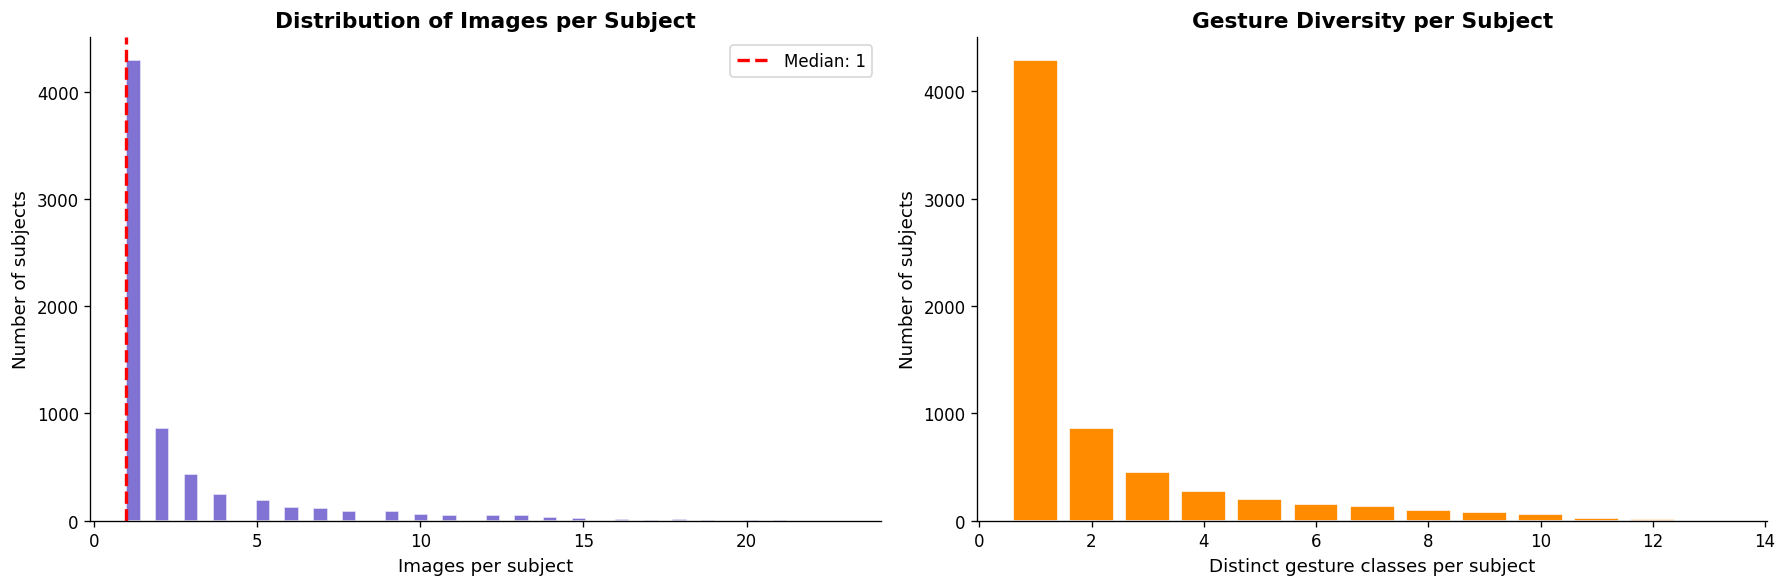

Total unique subjects  : 6,812
Median images/subject  : 1
Max images/subject     : 23
Mean gestures/subject  : 2.1


In [19]:
user_img_counts = df_img.groupby("user_id")["img_id"].nunique()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── 9.1 Images per subject ───────────────────────────────────────────
ax = axes[0]
ax.hist(user_img_counts.values, bins=50, color="slateblue", edgecolor="white", alpha=0.85)
ax.axvline(user_img_counts.median(), color="red", lw=2, ls="--",
           label=f"Median: {user_img_counts.median():.0f}")
ax.set_xlabel("Images per subject")
ax.set_ylabel("Number of subjects")
ax.set_title("Distribution of Images per Subject", fontweight="bold")
ax.legend()

# ── 9.2 Gesture diversity per subject ───────────────────────────────────
user_gesture_counts = (
    df_img[~df_img["gesture_class"].eq("no_gesture")]
    .groupby("user_id")["gesture_class"]
    .nunique()
)
ax = axes[1]
vc = user_gesture_counts.value_counts().sort_index()
ax.bar(vc.index, vc.values, color="darkorange", edgecolor="white")
ax.set_xlabel("Distinct gesture classes per subject")
ax.set_ylabel("Number of subjects")
ax.set_title("Gesture Diversity per Subject", fontweight="bold")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "subject_analysis.png", bbox_inches="tight")
plt.show()

print(f"Total unique subjects  : {len(user_img_counts):,}")
print(f"Median images/subject  : {user_img_counts.median():.0f}")
print(f"Max images/subject     : {user_img_counts.max()}")
print(f"Mean gestures/subject  : {user_gesture_counts.mean():.1f}")


In [20]:
# ── 9.3 Subject overlap across splits ─────────────────────────────────────
split_users = {
    split: set(df_img[df_img["split"] == split]["user_id"].dropna())
    for split in df_img["split"].unique()
}

print("Subject counts per split:")
for split, users in split_users.items():
    print(f"  {split:<8}: {len(users):,} unique subjects")

splits = list(split_users.keys())
print("\nSubject overlap between splits:")
for i in range(len(splits)):
    for j in range(i + 1, len(splits)):
        overlap = split_users[splits[i]] & split_users[splits[j]]
        print(f"  {splits[i]} ∩ {splits[j]}: {len(overlap):,} subjects")

Subject counts per split:
  train   : 5,912 unique subjects
  val     : 1,366 unique subjects
  test    : 1,361 unique subjects

Subject overlap between splits:
  train ∩ val: 913 subjects
  train ∩ test: 890 subjects
  val ∩ test: 397 subjects


---
<a id='10'></a>
## 10. Summary Dashboard

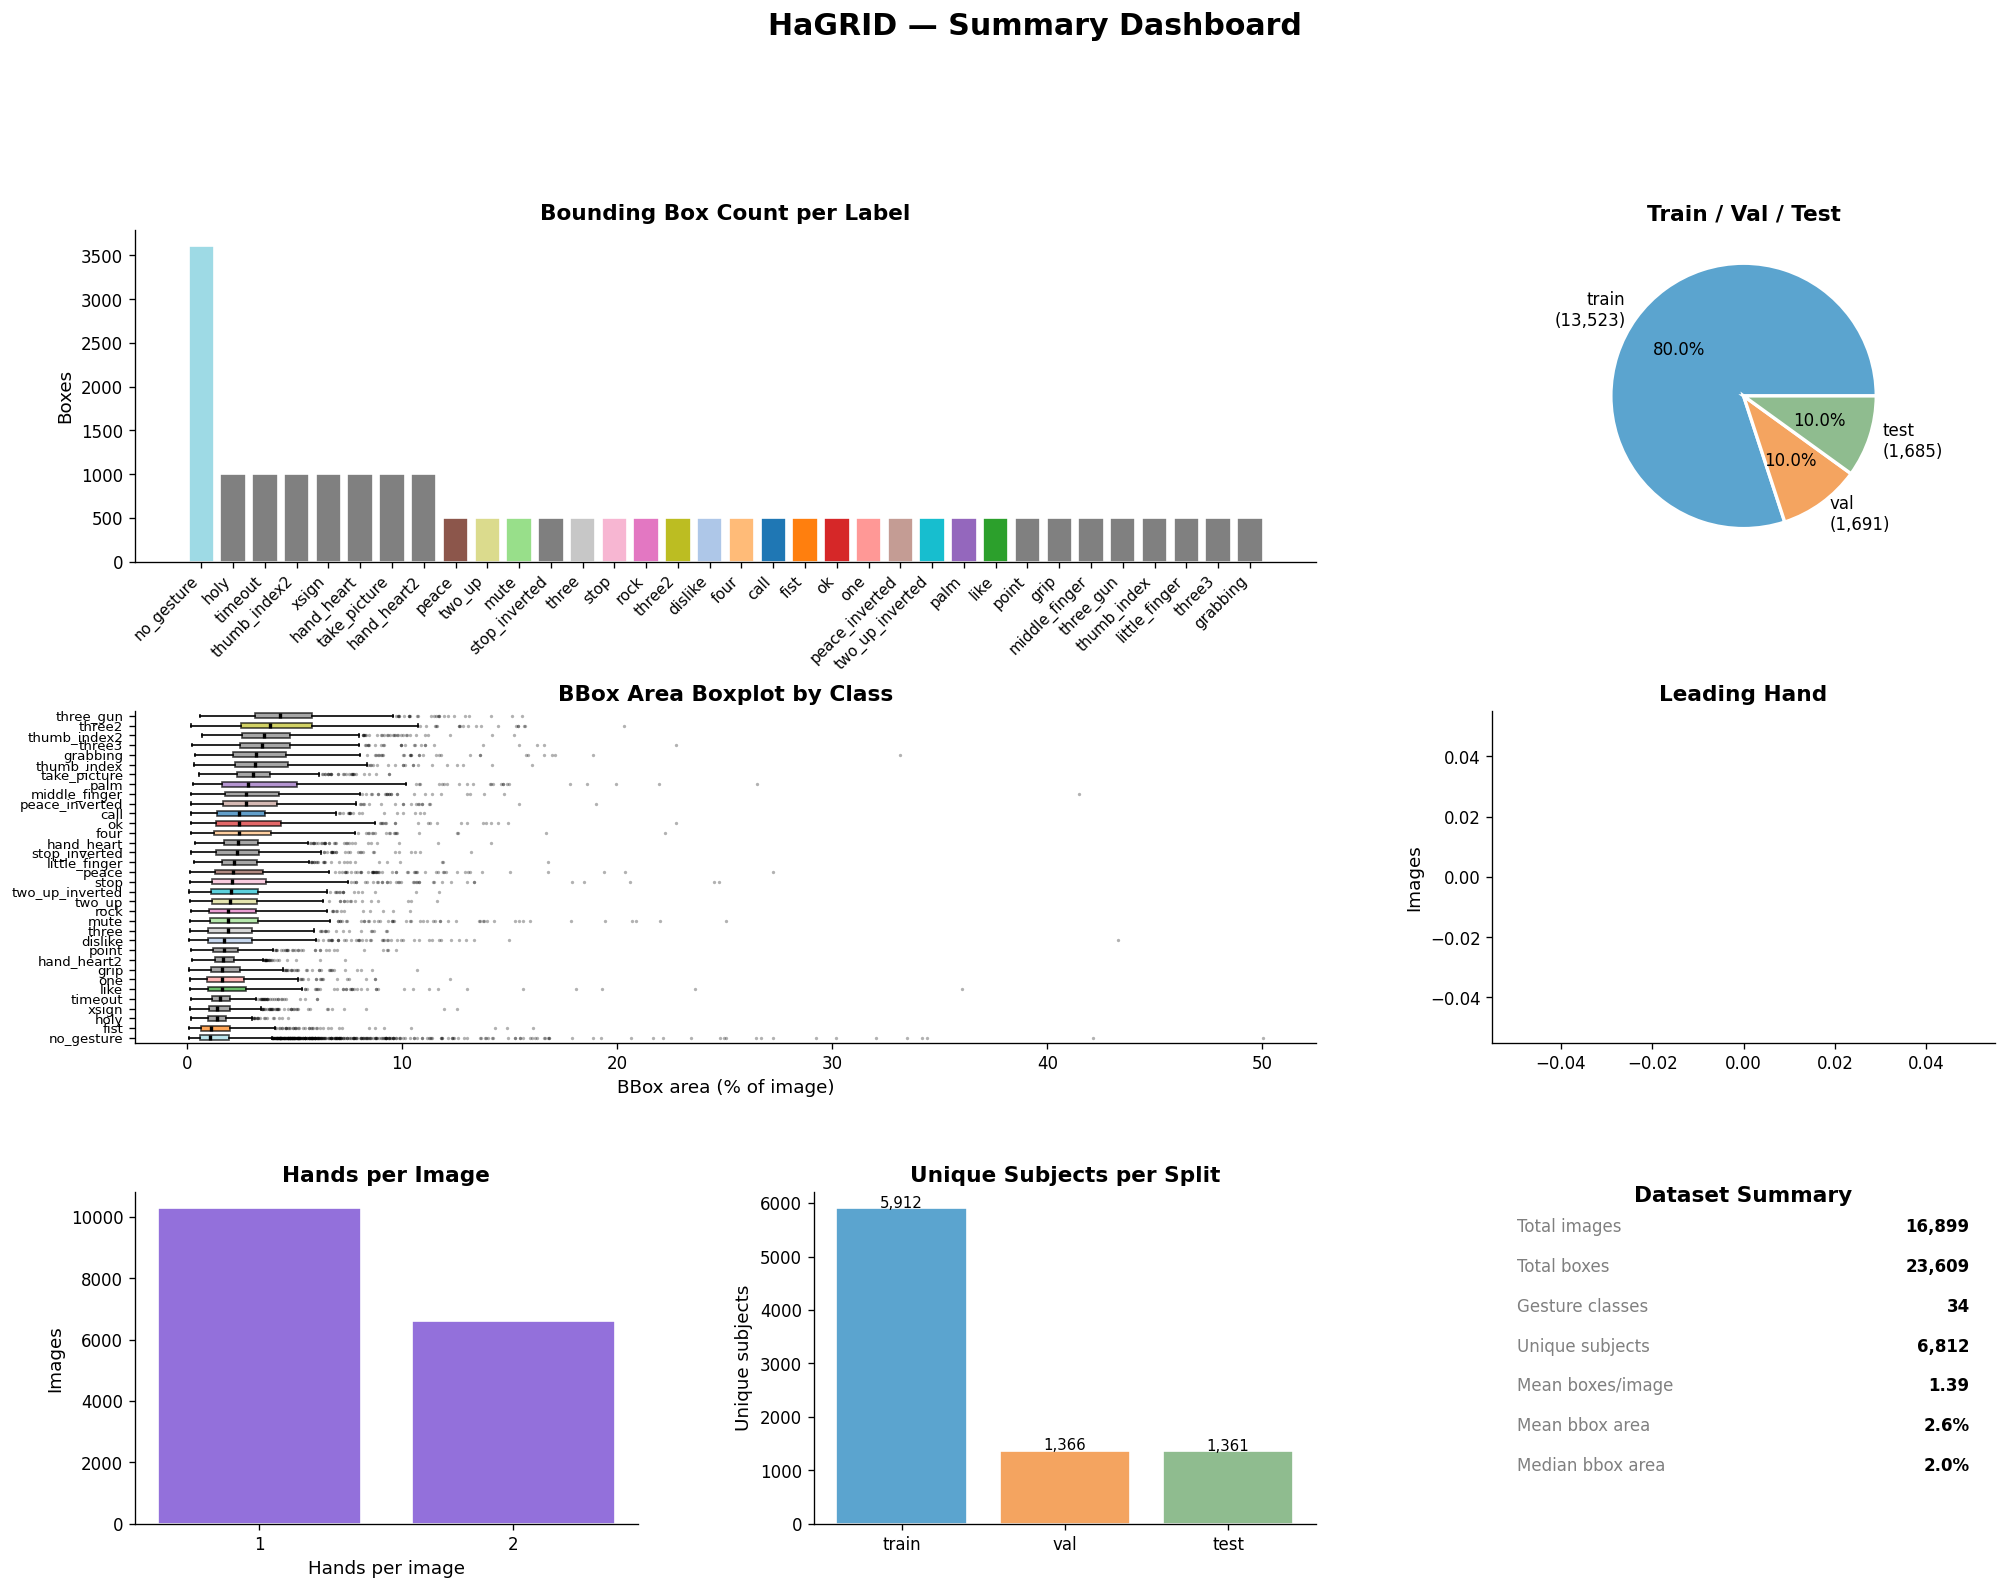

All plots saved to /content/hagrid_outputs


In [21]:
fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# A — box count per label
ax_a = fig.add_subplot(gs[0, :2])
lc   = df["label"].value_counts()
cols = [COLOR_MAP.get(l, (0.5, 0.5, 0.5, 1)) for l in lc.index]
ax_a.bar(range(len(lc)), lc.values, color=cols, edgecolor="white")
ax_a.set_xticks(range(len(lc)))
ax_a.set_xticklabels(lc.index, rotation=45, ha="right", fontsize=9)
ax_a.set_ylabel("Boxes")
ax_a.set_title("Bounding Box Count per Label", fontweight="bold")

# B — train / val / test split
ax_b = fig.add_subplot(gs[0, 2])
ss = df_img["split"].value_counts()
ax_b.pie(ss.values,
         labels=[f"{k}\n({v:,})" for k, v in ss.items()],
         colors=["#5BA4CF", "#F4A460", "#8FBC8F"],
         autopct="%1.1f%%",
         wedgeprops=dict(edgecolor="white", linewidth=2))
ax_b.set_title("Train / Val / Test", fontweight="bold")

# C — area boxplot per class
ax_c = fig.add_subplot(gs[1, :2])
g_order = df.groupby("label")["bbox_area"].median().sort_values().index.tolist()
bpdata  = [df[df["label"] == g]["bbox_area"].values * 100 for g in g_order]
bp = ax_c.boxplot(bpdata, vert=False, patch_artist=True,
                  medianprops=dict(color="black", lw=2),
                  flierprops=dict(marker=".", ms=2, alpha=0.3))
for patch, label in zip(bp["boxes"], g_order):
    patch.set_facecolor(COLOR_MAP.get(label, (0.5, 0.5, 0.5, 1)))
    patch.set_alpha(0.7)
ax_c.set_yticks(range(1, len(g_order) + 1))
ax_c.set_yticklabels(g_order, fontsize=8)
ax_c.set_xlabel("BBox area (% of image)")
ax_c.set_title("BBox Area Boxplot by Class", fontweight="bold")

# D — leading hand
ax_d = fig.add_subplot(gs[1, 2])
lh = df_img["leading_hand"].value_counts().dropna()
ax_d.bar(lh.index, lh.values, color=["#4C9BE8", "#E85C4C"], edgecolor="white")
ax_d.set_ylabel("Images")
ax_d.set_title("Leading Hand", fontweight="bold")
for i, v in enumerate(lh.values):
    ax_d.text(i, v + 50, f"{v:,}", ha="center", fontsize=9)

# E — hands per image
ax_e = fig.add_subplot(gs[2, 0])
hpi = df_img["n_hands"].value_counts().sort_index()
ax_e.bar(hpi.index.astype(str), hpi.values, color="mediumpurple", edgecolor="white")
ax_e.set_xlabel("Hands per image")
ax_e.set_ylabel("Images")
ax_e.set_title("Hands per Image", fontweight="bold")

# F — subjects per split
ax_f = fig.add_subplot(gs[2, 1])
ups = df_img.groupby("split")["user_id"].nunique().sort_values(ascending=False)
ax_f.bar(ups.index, ups.values,
         color=["#5BA4CF", "#F4A460", "#8FBC8F"][:len(ups)], edgecolor="white")
ax_f.set_ylabel("Unique subjects")
ax_f.set_title("Unique Subjects per Split", fontweight="bold")
for i, v in enumerate(ups.values):
    ax_f.text(i, v + 10, f"{v:,}", ha="center", fontsize=9)

# G — key stats text panel
ax_g = fig.add_subplot(gs[2, 2])
ax_g.axis("off")
stats = [
    ("Total images",      f"{df_img['img_id'].nunique():,}"),
    ("Total boxes",       f"{len(df):,}"),
    ("Gesture classes",   str(df['label'].nunique())),
    ("Unique subjects",   f"{df_img['user_id'].nunique():,}"),
    ("Mean boxes/image",  f"{df_img['n_boxes'].mean():.2f}"),
    ("Mean bbox area",    f"{df['bbox_area'].mean()*100:.1f}%"),
    ("Median bbox area",  f"{df['bbox_area'].median()*100:.1f}%"),
]
ax_g.text(0.5, 1.02, "Dataset Summary", ha="center", va="top",
          fontsize=13, fontweight="bold", transform=ax_g.transAxes)
y = 0.88
for k, v in stats:
    ax_g.text(0.05, y, k, ha="left", fontsize=10, color="grey", transform=ax_g.transAxes)
    ax_g.text(0.95, y, v, ha="right", fontsize=10, fontweight="bold", transform=ax_g.transAxes)
    y -= 0.12

fig.suptitle("HaGRID — Summary Dashboard", fontsize=18, fontweight="bold", y=1.01)
plt.savefig(OUTPUT_DIR / "hagrid_dashboard.png", bbox_inches="tight", dpi=140)
plt.show()
print(f"All plots saved to {OUTPUT_DIR}")

---
<a id='11'></a>
## 11. Save Outputs to Google Drive *(optional)*

All plots are saved automatically to `/content/hagrid_outputs/`.  
Use one of the options below to download them.


In [22]:
# ── Option A: Copy to Google Drive ───────────────────────────────────────
from google.colab import drive
drive.mount("/content/drive")

DRIVE_OUTPUT = Path("/content/drive/MyDrive/hagrid_outputs")
DRIVE_OUTPUT.mkdir(parents=True, exist_ok=True)

for f in OUTPUT_DIR.glob("*.png"):
    shutil.copy(f, DRIVE_OUTPUT / f.name)
    print(f"  Copied: {f.name}")

print(f"\nAll plots copied to Google Drive → {DRIVE_OUTPUT}")

Mounted at /content/drive
  Copied: leading_conf.png
  Copied: bbox_analysis.png
  Copied: leading_hand.png
  Copied: class_pie.png
  Copied: no_gesture_ratio.png
  Copied: bbox_wh_scatter.png
  Copied: subject_analysis.png
  Copied: hagrid_dashboard.png
  Copied: class_distribution.png

All plots copied to Google Drive → /content/drive/MyDrive/hagrid_outputs


In [23]:
# ── Option B: Download as zip to local machine ────────────────────────────
import zipfile as _zf
from google.colab import files

zip_path = "/content/hagrid_outputs.zip"
with _zf.ZipFile(zip_path, "w", _zf.ZIP_DEFLATED) as zf:
    for f in OUTPUT_DIR.glob("*.png"):
        zf.write(f, arcname=f.name)

files.download(zip_path)
print("hagrid_outputs.zip downloaded")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

hagrid_outputs.zip downloaded


---
## Appendix — Output Files

| File | Description |
|---|---|
| `class_distribution.png` | Bar + stacked bar of class balance |
| `donut_gesture_share.png` | Gesture class share (pie/donut) |
| `no_gesture_ratio.png` | no_gesture fraction per class |
| `bbox_distributions.png` | Area / aspect-ratio / W×H histograms |
| `bbox_scatter.png` | Width vs height scatter |
| `bbox_stats_per_class.csv` | Per-class bbox statistics table |
| `leading_hand.png` | Hand dominance plots |
| `leading_conf.png` | Dominance confidence histogram |
| `subject_analysis.png` | Images/subject + top subjects |
| `split_overlap.png` | Subject overlap across splits |
| `summary_dashboard.png` | Combined summary figure |

**Dataset source:** [`GestureDetectionConnoisseurs/hagrid_subsets`](https://huggingface.co/datasets/GestureDetectionConnoisseurs/hagrid_subsets)  
**License:** CC BY-SA 4.0
